## 1. THRESHOLDING

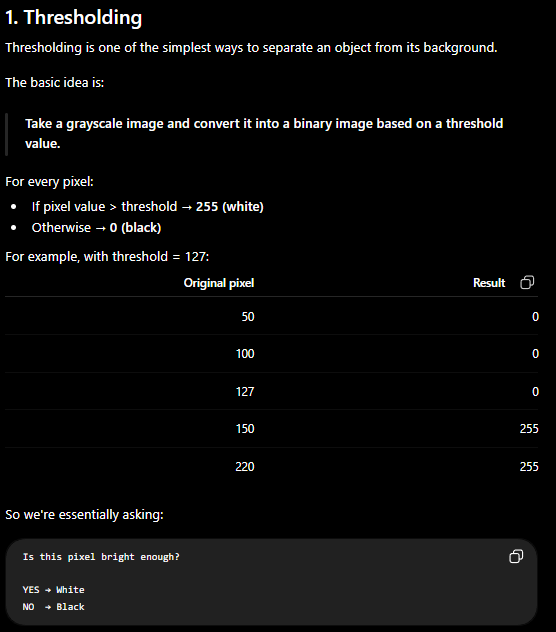

In [11]:
import cv2 as cv 

image=cv.imread("tank.png")
gray=cv.cvtColor(image,cv.COLOR_BGR2GRAY)
cv.imshow("gray",gray)

threshold , binary=cv.threshold(gray, 120,255,cv.THRESH_BINARY_INV)


cv.imshow("Gray", gray)
cv.imshow("Binary", binary)

cv.waitKey(0)
cv.destroyAllWindows()

print("Threshold:", threshold)

Threshold: 120.0


## 1.2 ADAPTIVE THRESHOLDING

In [44]:
image=cv.imread("tank.png")
gray=cv.cvtColor(image, cv.COLOR_BGR2GRAY)

#!                                 maxval ,      adaptiveMethod          ,  thresholdType   , blockSize , C
adaptive=cv.adaptiveThreshold(gray , 255 , cv.ADAPTIVE_THRESH_MEAN_C , cv.THRESH_BINARY , 5 , 3)

cv.imshow("adaptive",adaptive)
cv.waitKey(0)
cv.destroyAllWindows()

# 2. BLUR

### 2.1 GAUSSIANBLUR

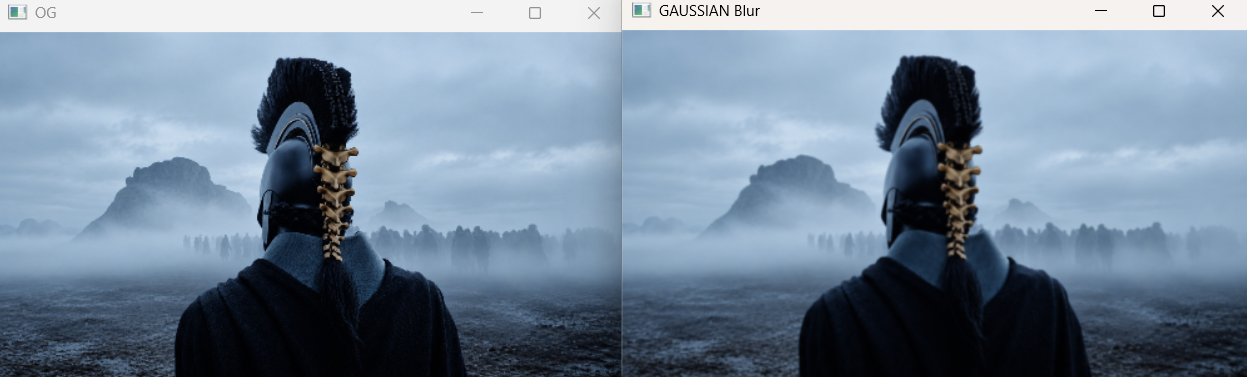
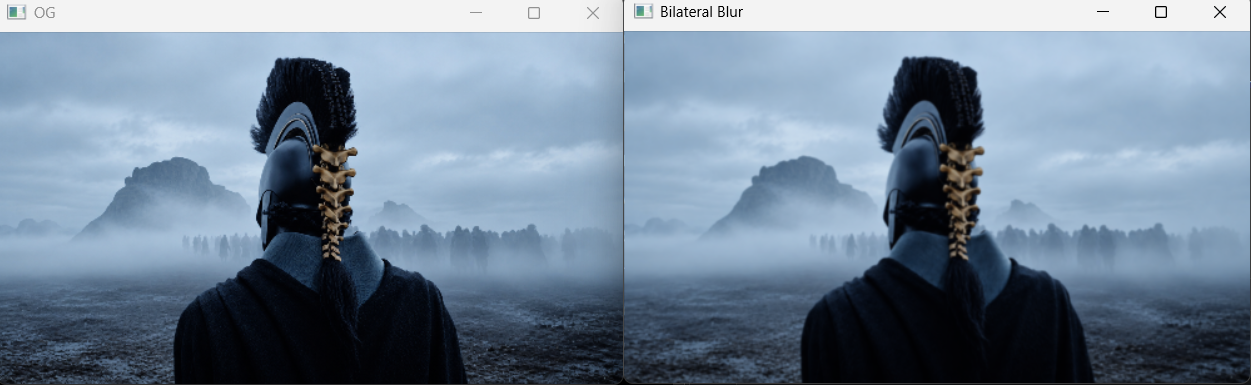

In [27]:
image=cv.imread("IMAGES/mem.png")
blur=cv.GaussianBlur(image , (11,11) ,0)

height, width = blur.shape[:2]

# Scale down
scale = 0.3
og_small = cv.resize(image,(int(width * scale), int(height * scale)))
small = cv.resize(blur,(int(width * scale), int(height * scale)))


cv.imshow("OG",og_small)
cv.imshow("GAUSSIAN Blur", small)

cv.waitKey(0)
cv.destroyAllWindows()

### 2.2 MEDIAN BLUR

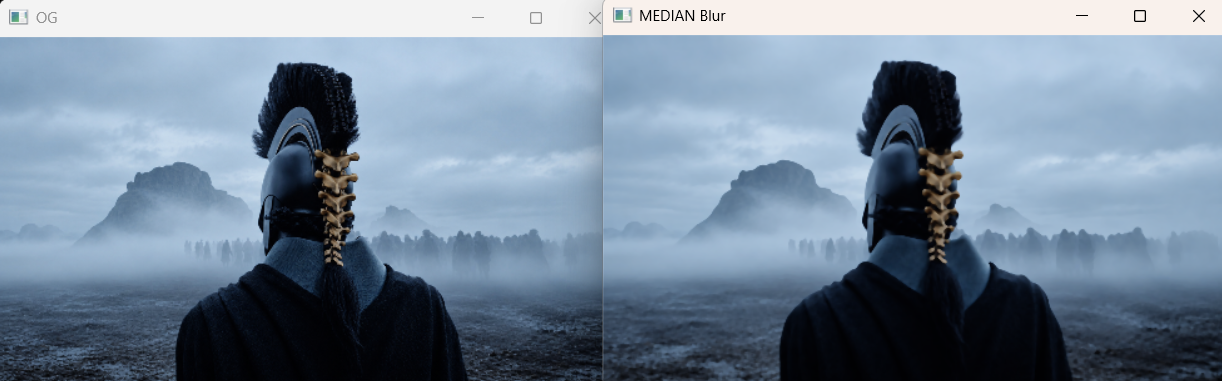](attachment:image.png)

In [33]:
image=cv.imread("IMAGES/mem.png")
m_blur=cv.medianBlur(image , 9)

height, width = m_blur.shape[:2]

# Scale down
scale = 0.3
og_small = cv.resize(image,(int(width * scale), int(height * scale)))
median_small = cv.resize(m_blur,(int(width * scale), int(height * scale)))


cv.imshow("OG",og_small)
cv.imshow("MEDIAN Blur", median_small)

cv.waitKey(0)
cv.destroyAllWindows()

### 2.3 BILATERLFILTER BLUR

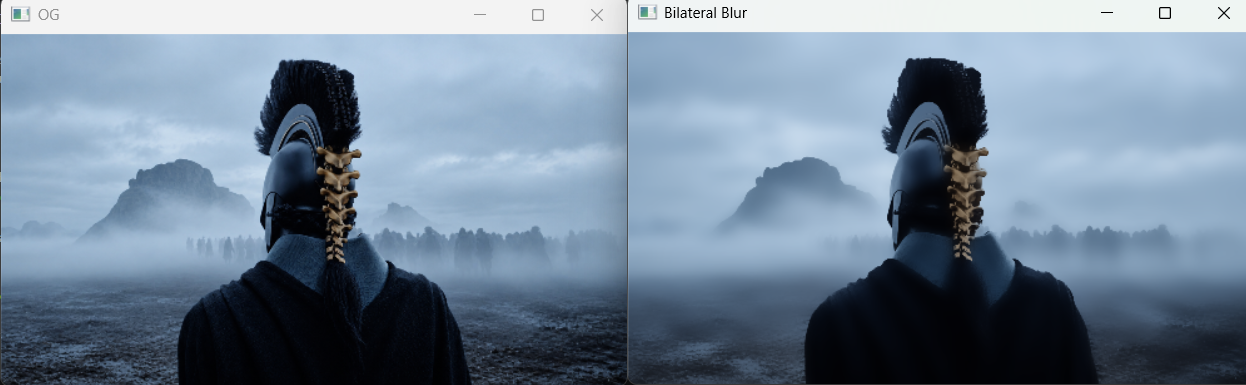

In [36]:
image = cv.imread("IMAGES/mem.png")

b_blur = cv.bilateralFilter(image, 55, 100, 100)

# Get original dimensions
height, width = b_blur.shape[:2]

# Scale down
scale = 0.3

small = cv.resize(b_blur,(int(width * scale), int(height * scale)))
og_small = cv.resize(image,(int(width * scale), int(height * scale)))

cv.imshow("OG",og_small)
cv.imshow("Bilateral Blur", small)
cv.waitKey(0)
cv.destroyAllWindows()

# 3. Morphological Operations

### 3.1 EROSION OPERATION

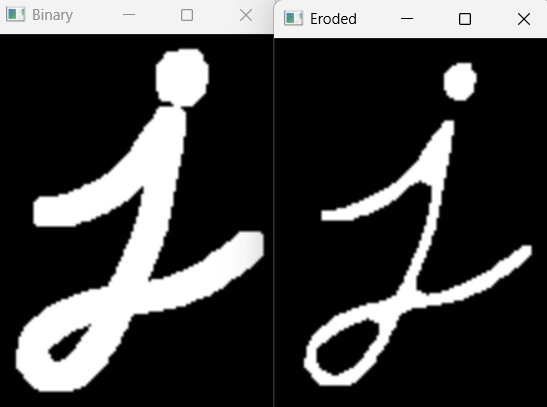

In [15]:
import cv2 as cv

image = cv.imread("IMAGES/dilation.png")
height, width = image.shape[:2] 

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

_, binary = cv.threshold(gray,127,255,cv.THRESH_BINARY)

kernel = cv.getStructuringElement(cv.MORPH_OPEN,(5, 5))

eroded = cv.erode(binary,kernel,iterations=2)


scale = 2
binary_small = cv.resize(binary,(int(width * scale), int(height * scale)))
small = cv.resize(eroded,(int(width * scale), int(height * scale)))


cv.imshow("Eroded", small)
cv.imshow("Binary", binary_small)
cv.waitKey(0)
cv.destroyAllWindows()

### 3.2 DILATED OPERATION

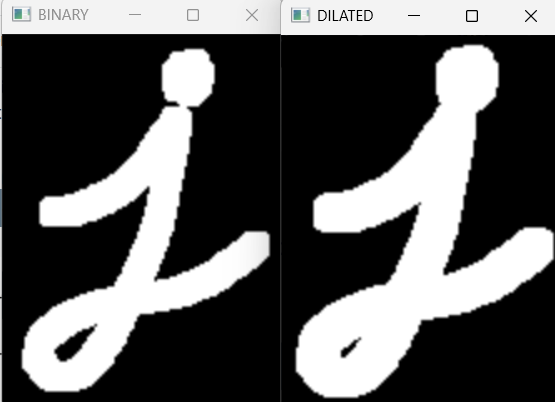

In [14]:
import cv2 as cv 
image=cv.imread("IMAGES/dilation.png")
height , width=image.shape[:2]

gray=cv.cvtColor(image,cv.COLOR_BGR2GRAY)
_,binary=cv.threshold(gray , 127 , 255 , cv.THRESH_BINARY)

kernel=cv.getStructuringElement(cv.MORPH_OPEN , (5,5))

dilated=cv.dilate(binary, kernel , iterations=1)
scale=2

binary_small=cv.resize(binary , (int(width * scale) , int(height * scale)))
small_dilated=cv.resize(dilated , (int(width * scale) , (int(height * scale))))

cv.imshow("BINARY", binary_small)
cv.imshow("DILATED",small_dilated)
cv.waitKey(0)
cv.destroyAllWindows()

### 3.3 OPENING OPERATION

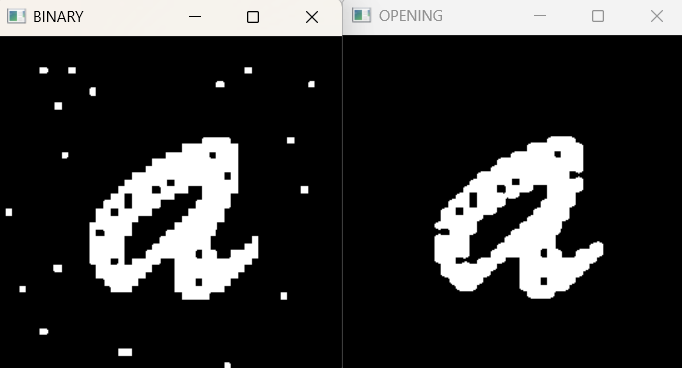

In [ ]:
import cv2 as cv

image = cv.imread("IMAGES/opening.png")
height, width = image.shape[:2] 

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

_, binary = cv.threshold(gray,127,255,cv.THRESH_BINARY)

kernel = cv.getStructuringElement(cv.MORPH_OPEN,(7, 7))

opening=cv.morphologyEx(binary , cv.MORPH_OPEN , kernel)

scale=1

binary_small=cv.resize(binary , (int(width * scale) , int(height * scale)))
small_opening=cv.resize(opening , (int(width * scale) , (int(height * scale))))

cv.imshow("BINARY", binary_small)
cv.imshow("OPENING",small_opening)
cv.waitKey(0)
cv.destroyAllWindows()


### 3.4 CLOSING OPERATION

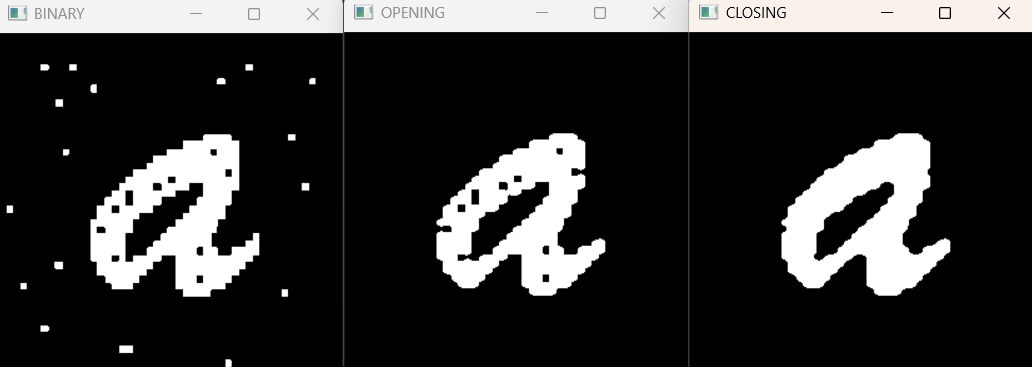

In [1]:
import cv2 as cv

image = cv.imread("IMAGES/opening.png")
height, width = image.shape[:2] 

gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)

_, binary = cv.threshold(gray,127,255,cv.THRESH_BINARY)

kernel = cv.getStructuringElement(cv.MORPH_OPEN,(7, 7))

opening=cv.morphologyEx(binary , cv.MORPH_OPEN , kernel)
closing=cv.morphologyEx(opening , cv.MORPH_CLOSE , kernel)

scale=1

binary_small=cv.resize(binary , (int(width * scale) , int(height * scale)))
small_opening=cv.resize(opening , (int(width * scale) , (int(height * scale))))
small_closing=cv.resize(closing , (int(width * scale) , (int(height * scale))))

cv.imshow("BINARY", binary_small)
cv.imshow("OPENING",small_opening)
cv.imshow("CLOSING", small_closing)
cv.waitKey(0)
cv.destroyAllWindows()


# 4. CANNY EDGE DETECTION

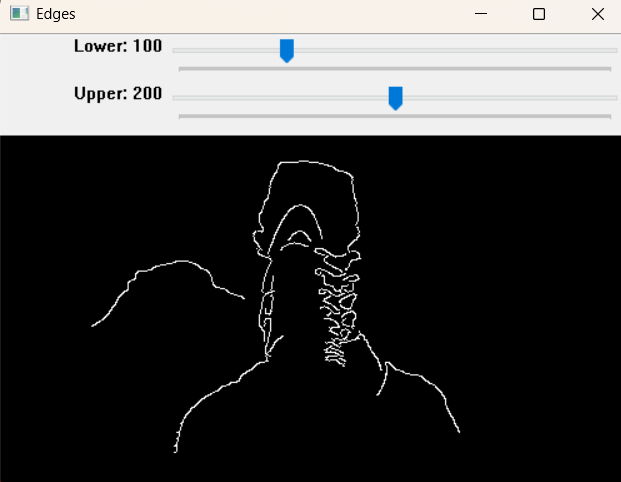

In [4]:
import cv2 as cv

# 1. Load and scale image to 30%
image = cv.imread("IMAGES/mem.png")
image = cv.resize(image, None, fx=0.3, fy=0.3, interpolation=cv.INTER_AREA)

# 2. Convert to grayscale and blur once (no need to do this inside the loop)
gray = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
blur = cv.GaussianBlur(gray, (9, 5), 0)

# 3. Setup window and trackbars
cv.namedWindow("Edges")
cv.createTrackbar("Lower", "Edges", 100, 400, lambda x: None)
cv.createTrackbar("Upper", "Edges", 200, 400, lambda x: None)

# 4. Main real-time adjustment loop
while True:
    # Get trackbar positions
    lower = cv.getTrackbarPos("Lower", "Edges")
    upper = cv.getTrackbarPos("Upper", "Edges")

    # Run edge detection and show output
    edges = cv.Canny(blur, lower, upper)
    cv.imshow("Edges", edges)

    # Press ESC (Key code 27) to exit cleanly
    if cv.waitKey(1) & 0xFF == 27:
        break

cv.destroyAllWindows()


# 5. IMAGE GRADIENT

### 5.1 SOBEL_X
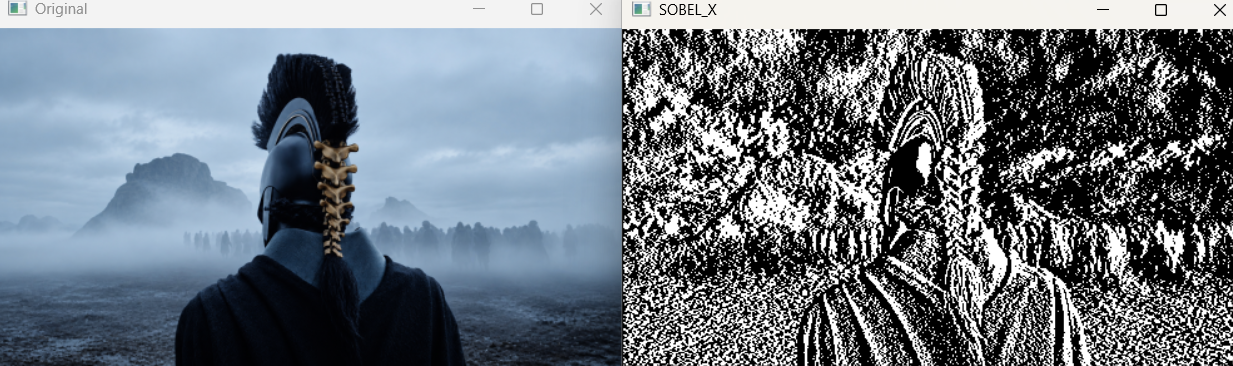

In [ ]:
import cv2 as cv 

image=cv.imread("IMAGES/mem.png")
image=cv.resize(image , None , fx=0.3 , fy=0.3 , interpolation=cv.INTER_AREA)

gray=cv.cvtColor(image, cv.COLOR_BGR2GRAY)

sobel_x=cv.Sobel(gray , cv.CV_64F, 1, 0, ksize=1)

cv.imshow("Original", image)
cv.imshow("SOBEL_X", sobel_x)
cv.waitKey(0)
cv.destroyAllWindows()

### 5.2 SOBEL_Y

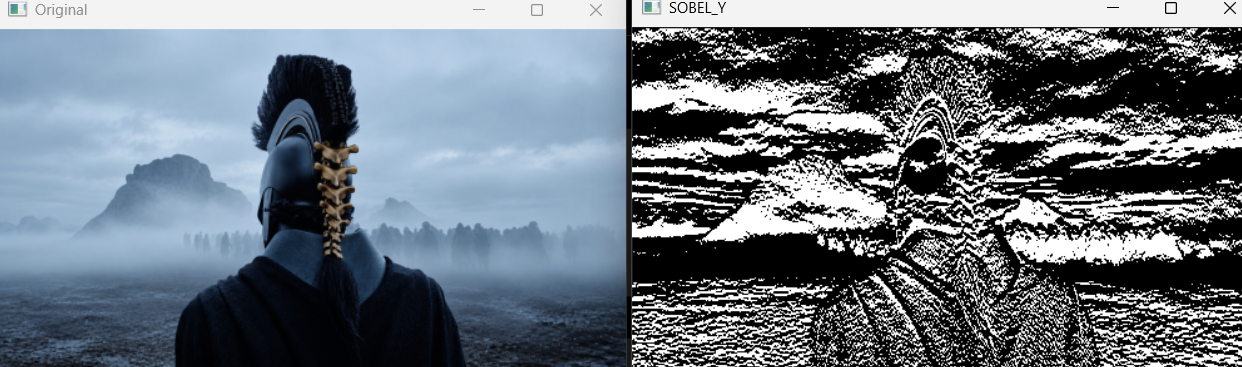

In [48]:
image=cv.imread("IMAGES/mem.png")
image=cv.resize(image , None , fx=0.3 , fy=0.3 , interpolation=cv.INTER_AREA)

gray=cv.cvtColor(image , cv.COLOR_BGR2GRAY)
sobel_y=cv.Sobel(gray , cv.CV_64F , 0 ,1 , ksize=1)

cv.imshow("Original", image)
cv.imshow("SOBEL_Y", sobel_y)
cv.waitKey(0)
cv.destroyAllWindows()

### 5.3 COMBINING BOTH